# Sprint 2 - US13 to US18

Descriptive statistics for Transparency Assessment

---

# US 13

In [2]:
## Importar Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import plotly
import scipy

In [3]:
# Load declaration-level data so each declaration is counted once.
declarations_df = pd.read_csv("../Dados/dataset1_declarations.csv")

In [4]:
# Prepare declaration-level data and shared summaries.
declarations_df = pd.read_csv("../Dados/dataset1_declarations.csv")

analysis_df = declarations_df.drop_duplicates(subset="declaration_id").copy()

print(f"Total rows loaded: {len(declarations_df)}")
print(f"Unique declarations after deduplication: {len(analysis_df)}")
print()

# Summary tables
declaration_type_counts = analysis_df["declaration_type"].value_counts().sort_index()
declaration_type_share = (declaration_type_counts / declaration_type_counts.sum() * 100).round(2)
role_counts = analysis_df["role"].value_counts().sort_values(ascending=False)
institution_counts = analysis_df["institution"].value_counts().sort_values(ascending=False)

print("Declaration type distribution (%):")
print(pd.DataFrame({"count": declaration_type_counts, "share_%": declaration_type_share}))
print()

print("Declarations by role:")
print(role_counts)
print()

print("Declarations by institution:")
print(institution_counts)
print()

# Shared theme for all charts
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "figure.facecolor": "white",
        "axes.facecolor": "#f8f9fa",
    }
)


Total rows loaded: 13395
Unique declarations after deduplication: 13395

Declaration type distribution (%):
                  count  share_%
declaration_type                
exceptional         860     6.42
initial            2364    17.65
regular           10171    75.93

Declarations by role:
role
Judge              8912
MP                 2360
Advisor            1572
State Secretary     376
Minister            175
Name: count, dtype: int64

Declarations by institution:
institution
Courts        8912
Parliament    2360
Government    2123
Name: count, dtype: int64



### Graph 1: Declaration Type Proportion

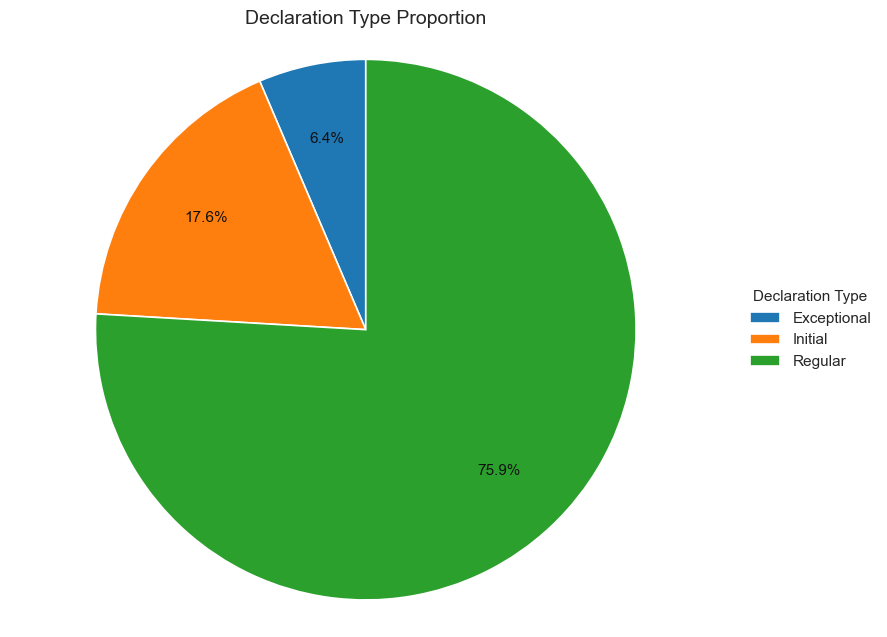

In [4]:
fig, ax = plt.subplots(figsize=(9, 6.5))

type_labels = [label.replace("_", " ").title() for label in declaration_type_counts.index]

wedges, _, autotexts = ax.pie(
    declaration_type_counts,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.72,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
)

for autotext in autotexts:
    autotext.set_color("#111111")
    autotext.set_fontsize(11)

ax.legend(
    wedges,
    type_labels,
    title="Declaration Type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

ax.set_title("Declaration Type Proportion")
ax.axis("equal")
plt.tight_layout()
plt.show()

### Graph 2: Total Declarations by Role

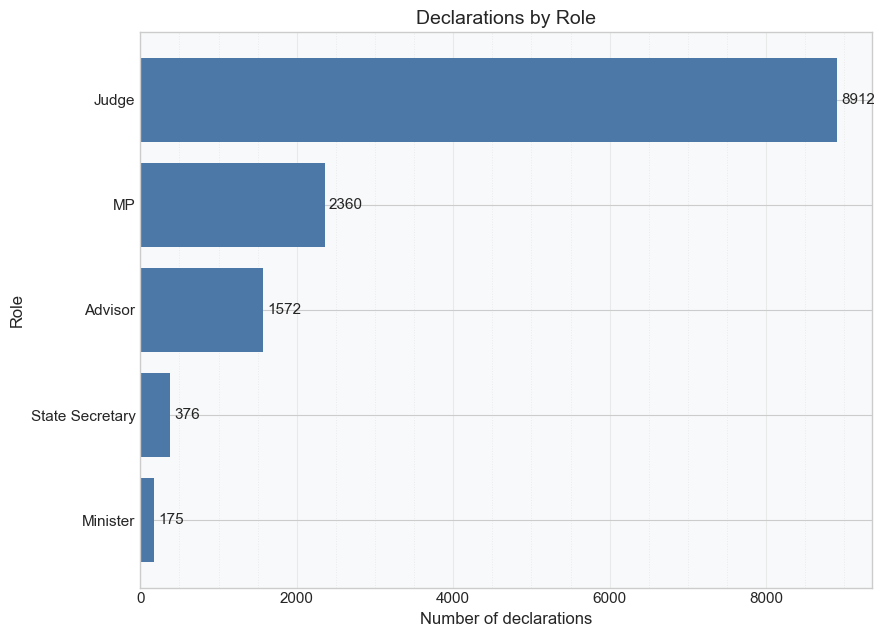

In [5]:
fig, ax = plt.subplots(figsize=(9, 6.5))

role_counts_plot = role_counts.sort_values(ascending=True)
role_bars = ax.barh(role_counts_plot.index, role_counts_plot.values, color="#4C78A8")

ax.set_title("Declarations by Role")
ax.set_xlabel("Number of declarations")
ax.set_ylabel("Role")
ax.set_axisbelow(True)
ax.minorticks_on()
ax.grid(axis="x", which="major", linestyle="-", linewidth=0.8, alpha=0.35)
ax.grid(axis="x", which="minor", linestyle=":", linewidth=0.7, alpha=0.30)
ax.bar_label(role_bars, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

### Graph 3: Total Declarations by Institution

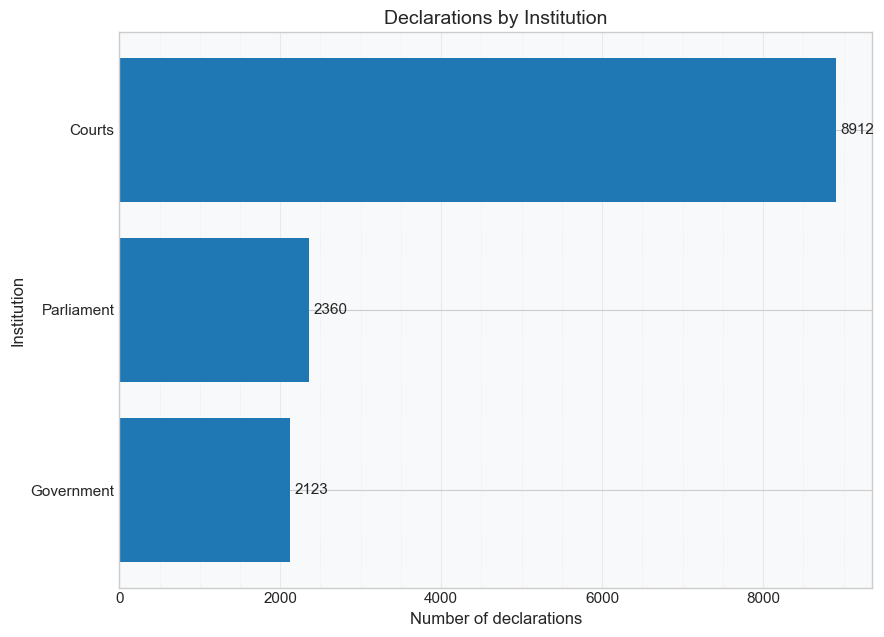

In [6]:
fig, ax = plt.subplots(figsize=(9, 6.5))

institution_counts_plot = institution_counts.sort_values(ascending=True)
institution_bars = ax.barh(
    institution_counts_plot.index,
    institution_counts_plot.values,
)

ax.set_title("Declarations by Institution")
ax.set_xlabel("Number of declarations")
ax.set_ylabel("Institution")
ax.set_axisbelow(True)
ax.minorticks_on()
ax.grid(axis="x", which="major", linestyle="-", linewidth=0.8, alpha=0.35)
ax.grid(axis="x", which="minor", linestyle=":", linewidth=0.7, alpha=0.30)
ax.bar_label(institution_bars, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

In [7]:
most_common_type = declaration_type_counts.idxmax()
most_common_type_count = int(declaration_type_counts.max())
most_common_role = role_counts.idxmax()
most_common_role_count = int(role_counts.max())
most_common_institution = institution_counts.idxmax()
most_common_institution_count = int(institution_counts.max())

print("Interpretation:")
print(
    f"- The most common declaration type is '{most_common_type}' with {most_common_type_count} declarations "
    f"({declaration_type_share[most_common_type]}% of the total)."
)
print(f"- The role with the most declarations is '{most_common_role}' with {most_common_role_count} declarations.")
print(
    f"- The institution with the most declarations is '{most_common_institution}' "
    f"with {most_common_institution_count} declarations."
)

Interpretation:
- The most common declaration type is 'regular' with 10171 declarations (75.93% of the total).
- The role with the most declarations is 'Judge' with 8912 declarations.
- The institution with the most declarations is 'Courts' with 8912 declarations.


# US 14

In [2]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# Carregar o dataset das declarações
declarations_df = pd.read_csv("../Dados/dataset1_declarations.csv")

# Converter a data para o formato datetime
declarations_df["declaration_date"] = pd.to_datetime(
    declarations_df["declaration_date"], errors="coerce"
)

# Garantir que as colunas numéricas estão no formato correto
numeric_columns = [
    "gross_salary",
    "side_income_consulting",
    "side_income_board_memberships",
    "assets_in_real_estate",
    "assets_in_vehicles",
    "assets_in_stocks",
]

for column in numeric_columns:
    declarations_df[column] = pd.to_numeric(declarations_df[column], errors="coerce")

# Remover linhas sem agente ou sem data, porque são necessárias para escolher a declaração mais recente
analysis_df = declarations_df.dropna(subset=["agent_id", "declaration_date"]).copy()

# Criar variáveis totais pedidas no enunciado
analysis_df["total_income"] = (
    analysis_df["gross_salary"].fillna(0)
    + analysis_df["side_income_consulting"].fillna(0)
    + analysis_df["side_income_board_memberships"].fillna(0)
)

analysis_df["total_assets"] = (
    analysis_df["assets_in_real_estate"].fillna(0)
    + analysis_df["assets_in_vehicles"].fillna(0)
    + analysis_df["assets_in_stocks"].fillna(0)
)

# Para cada agente político, considerar apenas a declaração mais recente
latest_declarations = (
    analysis_df.sort_values(["agent_id", "declaration_date"])
    .drop_duplicates(subset="agent_id", keep="last")
    .copy()
)

print(f"Total de declarações no dataset: {len(declarations_df)}")
print(f"Declarações mais recentes consideradas: {len(latest_declarations)}")
latest_declarations.head()


Total de declarações no dataset: 13395
Declarações mais recentes consideradas: 2364


,agent_id,role,declaration_type,declaration_date,declaration_id,institution,gross_salary,side_income_consulting,side_income_board_memberships,assets_in_real_estate,assets_in_vehicles,assets_in_stocks,total_income,total_assets
2,A00001,MP,regular,2026-01-15,D000002,Parliament,61227.440378,26782.410048,9141.892217,16945.613880,4244.493958,29924.280475,97151.742643,51114.388314
10,A00002,MP,regular,2026-01-15,D000010,Parliament,57375.603650,2160.907291,28786.217969,31307.245383,23585.301270,6891.053695,88322.728910,61783.600348
18,A00003,MP,regular,2026-01-15,D000018,Parliament,59624.595619,51260.243645,9943.989849,414.754603,50615.983385,18889.226093,120828.829113,69919.964081
26,A00004,MP,regular,2026-01-15,D000026,Parliament,50857.316968,9467.933636,19170.525593,2037.358169,13464.043085,16588.249485,79495.776197,32089.650740
31,A00005,MP,regular,2026-01-15,D000031,Parliament,67297.524657,13334.391476,128525.296248,34017.852685,26649.856645,15998.666148,209157.212382,76666.375478


### Medidas descritivas

In [3]:
# Função simples para calcular medidas de localização e variabilidade
def descriptive_measures(series):
    return pd.Series({
        "count": series.count(),
        "mean": series.mean(),
        "median": series.median(),
        "mode": series.mode().iloc[0] if not series.mode().empty else np.nan,
        "min": series.min(),
        "max": series.max(),
        "range": series.max() - series.min(),
        "variance": series.var(),
        "std_dev": series.std(),
        "q1": series.quantile(0.25),
        "q3": series.quantile(0.75),
        "iqr": series.quantile(0.75) - series.quantile(0.25),
    })

# Calcular as medidas para rendimento total e património total
summary_stats = pd.DataFrame({
    "total_income": descriptive_measures(latest_declarations["total_income"]),
    "total_assets": descriptive_measures(latest_declarations["total_assets"]),
})

summary_stats.round(2)


,total_income,total_assets
count,2.364000e+03,2.364000e+03
mean,9.988131e+04,5.937253e+04
median,9.573734e+04,5.368864e+04
mode,2.335001e+04,1.772460e+03
min,2.335001e+04,1.772460e+03
max,2.564204e+05,2.438996e+05
range,2.330704e+05,2.421271e+05
variance,1.008252e+09,1.189392e+09
std_dev,3.175298e+04,3.448756e+04
q1,7.799904e+04,3.406546e+04


### Distribuição do rendimento total

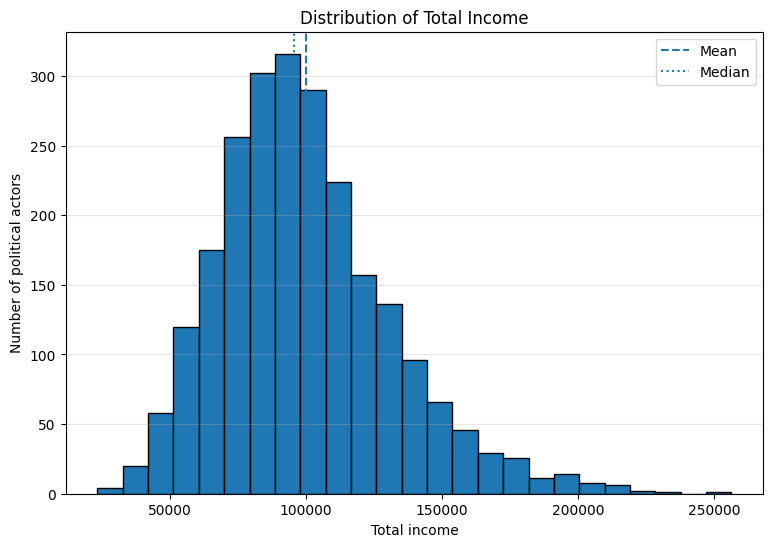

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))

# Histograma para observar a forma da distribuição do rendimento total
ax.hist(latest_declarations["total_income"], bins=25, edgecolor="black")
ax.axvline(latest_declarations["total_income"].mean(), linestyle="--", label="Mean")
ax.axvline(latest_declarations["total_income"].median(), linestyle=":", label="Median")

ax.set_title("Distribution of Total Income")
ax.set_xlabel("Total income")
ax.set_ylabel("Number of political actors")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.show()


### Distribuição do património total

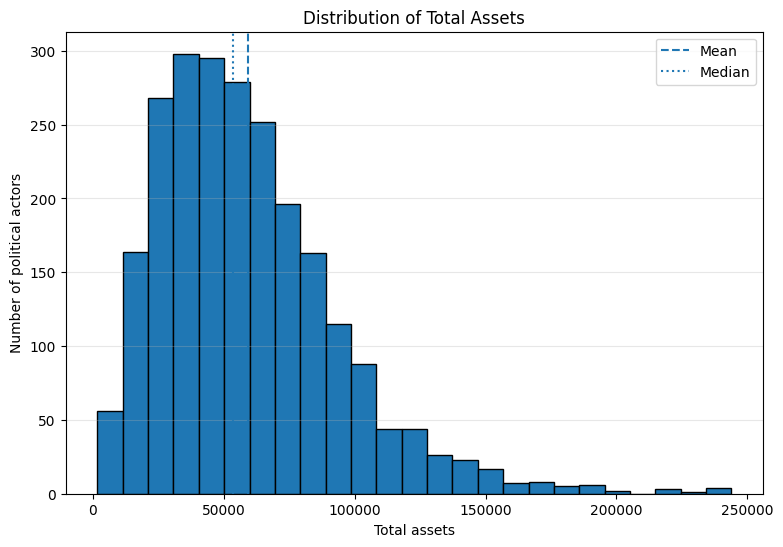

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

# Histograma para observar a forma da distribuição do património total
ax.hist(latest_declarations["total_assets"], bins=25, edgecolor="black")
ax.axvline(latest_declarations["total_assets"].mean(), linestyle="--", label="Mean")
ax.axvline(latest_declarations["total_assets"].median(), linestyle=":", label="Median")

ax.set_title("Distribution of Total Assets")
ax.set_xlabel("Total assets")
ax.set_ylabel("Number of political actors")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.show()


### Comparação visual da variabilidade

/tmp/ipykernel_129410/1388946673.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


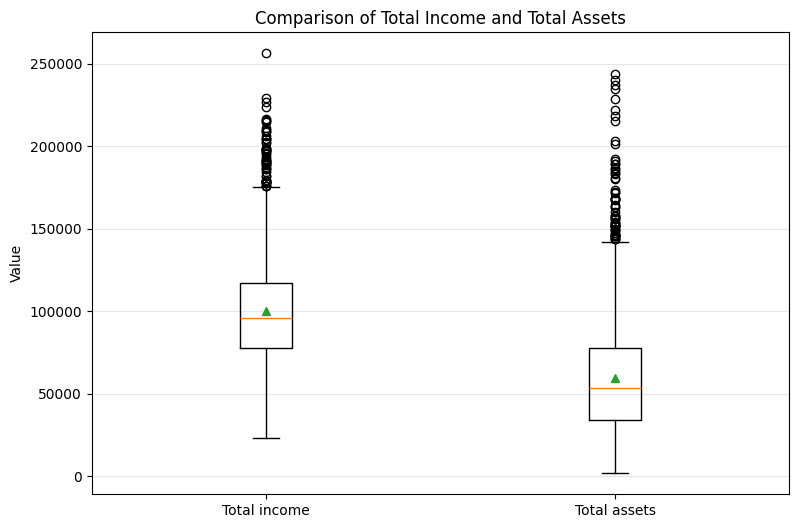

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

# Boxplot para comparar dispersão e possíveis outliers
ax.boxplot(
    [latest_declarations["total_income"], latest_declarations["total_assets"]],
    labels=["Total income", "Total assets"],
    showmeans=True,
)

ax.set_title("Comparison of Total Income and Total Assets")
ax.set_ylabel("Value")
ax.grid(axis="y", alpha=0.3)

plt.show()


### Interpretação simples

In [7]:
income_mean = latest_declarations["total_income"].mean()
income_median = latest_declarations["total_income"].median()
assets_mean = latest_declarations["total_assets"].mean()
assets_median = latest_declarations["total_assets"].median()

print("Simple interpretation:")

if income_mean > income_median:
    print("- Total income is right-skewed: some political actors have much higher income than the majority.")
else:
    print("- Total income is relatively balanced around the centre.")

if assets_mean > assets_median:
    print("- Total assets are right-skewed: some political actors have much higher assets than the majority.")
else:
    print("- Total assets are relatively balanced around the centre.")

print("- The boxplot helps identify dispersion and possible outliers in both variables.")
print("- Only the most recent declaration of each political actor was used, as required in the user story.")


Simple interpretation:
- Total income is right-skewed: some political actors have much higher income than the majority.
- Total assets are right-skewed: some political actors have much higher assets than the majority.
- The boxplot helps identify dispersion and possible outliers in both variables.
- Only the most recent declaration of each political actor was used, as required in the user story.


# US 15 — Evolução Temporal dos Rendimentos e Bens de um Agente Político

**Descrição:**  
Como membro do Comité de Ética, quero examinar como os rendimentos e o património de um determinado agente político evoluem ao longo do tempo. Esta análise produz três gráficos separados:

1. Evolução do **salário bruto** ao longo de todas as declarações.
2. Evolução dos **rendimentos suplementares**, distinguindo os diferentes tipos.
3. Evolução dos **bens declarados**, distinguindo as diferentes categorias de ativos.

São consideradas **todas** as declarações do agente: initial, regular e exceptional, ordenadas cronologicamente.

---

## Conceitos Teóricos Aplicados

### Série Temporal
Uma série temporal é um conjunto de observações $\{x_t\}$ ordenadas no tempo $t_1 < t_2 < \ldots < t_n$.  
Cada declaração de interesses constitui uma observação num instante de tempo $t_i$.

### Tendência (Trend)
A tendência representa a direção geral da série ao longo do tempo:  
- **Crescente**: o valor aumenta progressivamente.
- **Decrescente**: o valor diminui progressivamente.
- **Estável**: sem variação sistemática ao longo do tempo.

### Total de Ativos Declarados
Como o dataset não inclui passivos, calcula-se o total de ativos declarados como:
$$\text{total\_assets}_t = \sum_{c \in \text{ASSET\_COLS}} \text{valor}_c(t)$$

### Gráfico de Linha (Line Chart)
Representação adequada para séries temporais: o eixo horizontal representa o tempo e o eixo vertical o valor observado. Permite identificar tendências, ciclos e variações abruptas entre declarações.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

In [3]:
def load_declarations_data(path: str):
    """Load and prepare the declarations dataset.

    Returns df, side_income_cols, asset_cols.
    Columns are detected automatically from column name prefixes.
    """
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df["declaration_date"] = pd.to_datetime(df["declaration_date"])

    side_income_cols = [col for col in df.columns if col.startswith("side_income_")]
    asset_cols       = [col for col in df.columns if col.startswith("assets_in_")]

    # total_assets: sum of all declared asset categories
    df["total_assets"] = df[asset_cols].sum(axis=1)

    return df, side_income_cols, asset_cols


DATA_PATH = "../Dados/dataset1_declarations.csv"
df, SIDE_INCOME_COLS, ASSET_COLS = load_declarations_data(DATA_PATH)

print(f"Dataset carregado  : {df.shape[0]} declarações, {df['agent_id'].nunique()} agentes únicos")
print(f"Side income cols   : {SIDE_INCOME_COLS}")
print(f"Asset cols         : {ASSET_COLS}")
print(f"Tipos de declaração: {sorted(df['declaration_type'].unique())}")

Dataset carregado  : 13395 declarações, 2364 agentes únicos
Side income cols   : ['side_income_consulting', 'side_income_board_memberships']
Asset cols         : ['assets_in_real_estate', 'assets_in_vehicles', 'assets_in_stocks']
Tipos de declaração: ['exceptional', 'initial', 'regular']


## Notas Metodológicas

### Net Worth

Como o dataset das declarações não inclui passivos, dívidas ou outros componentes patrimoniais negativos (e.g., `liabilities`, `debts`, `loans`), não é possível calcular diretamente o valor líquido patrimonial (*net worth*). Assim, esta análise usa os **ativos declarados por categoria** e calcula `total_assets` como a soma das categorias de ativos disponíveis.

### Dataset 2 — Holdings

O ficheiro `dataset2_holdings.csv` contém informação detalhada ao nível empresa sobre participações acionistas (NIF da empresa, valor total em ações, percentagem da empresa). No entanto, **não é utilizado como fonte principal nesta US15** porque:
- não contém `declaration_id`, impossibilitando a ligação direta às declarações;
- as datas não correspondem diretamente às datas das declarações do dataset 1.

O valor de ações declarado utilizado nesta análise provém da coluna `assets_in_stocks` do `dataset1_declarations.csv`, que agrega o valor total de ações por declaração.

In [4]:
# ── Funções de extração de dados ─────────────────────────────────────────────

def get_actor_declarations(df: pd.DataFrame, agent_id: str) -> pd.DataFrame:
    """Filter all declarations for a given agent, sorted by date.

    Includes all declaration types: initial, regular, exceptional.
    """
    actor_df = df[df["agent_id"] == agent_id].copy()
    if actor_df.empty:
        raise ValueError(f"Agente '{agent_id}' não encontrado no dataset.")
    return actor_df.sort_values("declaration_date").reset_index(drop=True)


def extract_gross_salary_series(actor_df: pd.DataFrame) -> pd.DataFrame:
    """Extract gross salary time series from actor declarations."""
    return actor_df[["declaration_date", "declaration_type", "gross_salary"]].copy()


def extract_side_income_series(actor_df: pd.DataFrame, side_income_cols: list) -> pd.DataFrame:
    """Melt side income columns into long format with readable type labels."""
    long_df = actor_df[["declaration_date", "declaration_type"] + side_income_cols].melt(
        id_vars=["declaration_date", "declaration_type"],
        value_vars=side_income_cols,
        var_name="side_income_type",
        value_name="amount",
    )
    long_df["side_income_type"] = (
        long_df["side_income_type"]
        .str.replace("side_income_", "", regex=False)
        .str.replace("_", " ")
        .str.title()
    )
    return long_df


def extract_assets_series(actor_df: pd.DataFrame, asset_cols: list) -> pd.DataFrame:
    """Melt asset columns into long format with readable category labels."""
    long_df = actor_df[["declaration_date", "declaration_type"] + asset_cols].melt(
        id_vars=["declaration_date", "declaration_type"],
        value_vars=asset_cols,
        var_name="asset_category",
        value_name="value",
    )
    long_df["asset_category"] = (
        long_df["asset_category"]
        .str.replace("assets_in_", "", regex=False)
        .str.replace("_", " ")
        .str.title()
    )
    return long_df


# ── Funções de visualização ───────────────────────────────────────────────────

def plot_gross_salary(gross_df: pd.DataFrame, agent_id: str) -> None:
    """Line chart of gross salary evolution over time.

    Uses distinct markers per declaration type.
    """
    marker_map = {"initial": "s", "regular": "o", "exceptional": "^"}
    color_map  = {"initial": "#2196F3", "regular": "#4CAF50", "exceptional": "#FF5722"}

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        gross_df["declaration_date"],
        gross_df["gross_salary"],
        color="#90A4AE", linewidth=1.2, linestyle="--", zorder=1,
    )

    for dtype, group in gross_df.groupby("declaration_type"):
        ax.scatter(
            group["declaration_date"],
            group["gross_salary"],
            label=dtype.capitalize(),
            marker=marker_map.get(dtype, "o"),
            color=color_map.get(dtype, "grey"),
            s=80, zorder=2,
        )

    ax.set_title(
        f"Evolution of Gross Salary — Agent {agent_id}",
        fontsize=14, fontweight="bold", pad=15,
    )
    ax.set_xlabel("Declaration date", fontsize=12)
    ax.set_ylabel("Gross salary (€)", fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €"))
    ax.legend(title="Declaration type", frameon=True)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.grid(axis="x", linestyle=":", alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("US15_gross_salary.svg", format="svg", bbox_inches="tight")
    plt.show()
    print("Gráfico guardado em: US15_gross_salary.svg")


def plot_side_income(side_income_df: pd.DataFrame, agent_id: str) -> None:
    """Multi-line chart of side income by type over time."""
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    tipos  = sorted(side_income_df["side_income_type"].unique())

    fig, ax = plt.subplots(figsize=(12, 6))

    for i, tipo in enumerate(tipos):
        grupo = (
            side_income_df[side_income_df["side_income_type"] == tipo]
            .sort_values("declaration_date")
        )
        ax.plot(
            grupo["declaration_date"],
            grupo["amount"],
            marker="o", linewidth=1.8, label=tipo,
            color=colors[i % len(colors)],
        )

    ax.set_title(
        f"Evolution of Side Income by Type — Agent {agent_id}",
        fontsize=14, fontweight="bold", pad=15,
    )
    ax.set_xlabel("Declaration date", fontsize=12)
    ax.set_ylabel("Side income amount (€)", fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €"))
    ax.legend(title="Income type", frameon=True)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.grid(axis="x", linestyle=":", alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("US15_side_income.svg", format="svg", bbox_inches="tight")
    plt.show()
    print("Gráfico guardado em: US15_side_income.svg")


def plot_assets(assets_df: pd.DataFrame, agent_id: str) -> None:
    """Multi-line chart of declared assets by category over time."""
    colors     = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    categorias = sorted(assets_df["asset_category"].unique())

    fig, ax = plt.subplots(figsize=(12, 6))

    for i, categoria in enumerate(categorias):
        grupo = (
            assets_df[assets_df["asset_category"] == categoria]
            .sort_values("declaration_date")
        )
        ax.plot(
            grupo["declaration_date"],
            grupo["value"],
            marker="o", linewidth=1.8, label=categoria,
            color=colors[(i + 3) % len(colors)],
        )

    ax.set_title(
        f"Evolution of Declared Assets by Category — Agent {agent_id}",
        fontsize=14, fontweight="bold", pad=15,
    )
    ax.set_xlabel("Declaration date", fontsize=12)
    ax.set_ylabel("Asset value (€)", fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €"))
    ax.legend(title="Asset category", frameon=True)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.grid(axis="x", linestyle=":", alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("US15_assets.svg", format="svg", bbox_inches="tight")
    plt.show()
    print("Gráfico guardado em: US15_assets.svg")


# ── Função de interpretação ───────────────────────────────────────────────────

def print_interpretation(
    actor_df: pd.DataFrame,
    gross_df: pd.DataFrame,
    side_income_df: pd.DataFrame,
    assets_df: pd.DataFrame,
    agent_id: str,
) -> None:
    """Print a descriptive interpretation of the three time series."""
    # Gross salary trend
    first_salary  = gross_df["gross_salary"].iloc[0]
    last_salary   = gross_df["gross_salary"].iloc[-1]
    salary_pct    = (last_salary - first_salary) / first_salary * 100
    salary_trend  = (
        "increasing" if salary_pct > 0
        else ("decreasing" if salary_pct < 0 else "stable")
    )

    # Side income
    mean_by_type    = side_income_df.groupby("side_income_type")["amount"].mean()
    top_income_type = mean_by_type.idxmax()

    # Assets
    mean_by_asset = assets_df.groupby("asset_category")["value"].mean()
    top_asset_cat = mean_by_asset.idxmax()

    # Total assets evolution
    first_total = actor_df["total_assets"].iloc[0]
    last_total  = actor_df["total_assets"].iloc[-1]
    assets_pct  = (last_total - first_total) / first_total * 100
    assets_trend = (
        "increasing" if assets_pct > 0
        else ("decreasing" if assets_pct < 0 else "stable")
    )

    type_counts = actor_df["declaration_type"].value_counts()

    print("=" * 70)
    print("DESCRIPTIVE INTERPRETATION")
    print("=" * 70)
    print(f"  Agent              : {agent_id}")
    print(f"  Role               : {actor_df['role'].iloc[0]}")
    print(f"  Declarations used  : {len(actor_df)} — {type_counts.to_dict()}")
    print(f"  Period             : {actor_df['declaration_date'].min().date()} "
          f"to {actor_df['declaration_date'].max().date()}")
    print()
    print(f"  Gross Salary — {salary_trend} trend ({salary_pct:+.1f}%)")
    print(f"    First declaration : {first_salary:>12,.0f} €")
    print(f"    Last declaration  : {last_salary:>12,.0f} €")
    print()
    print(f"  Side Income — most relevant type by average: {top_income_type}")
    for tipo, media in mean_by_type.sort_values(ascending=False).items():
        print(f"    {tipo:<28}: {media:>10,.0f} €")
    print()
    print(f"  Declared Assets — largest average category: {top_asset_cat}")
    for cat, media in mean_by_asset.sort_values(ascending=False).items():
        print(f"    {cat:<28}: {media:>10,.0f} €")
    print()
    print(f"  Total Assets — {assets_trend} trend ({assets_pct:+.1f}%)")
    print(f"    First declaration : {first_total:>12,.0f} €")
    print(f"    Last declaration  : {last_total:>12,.0f} €")
  
    print("=" * 70)


# ── Função principal ──────────────────────────────────────────────────────────

def run_us15_analysis(
    df: pd.DataFrame,
    side_income_cols: list,
    asset_cols: list,
    selected_agent_id: str,
) -> None:
    """Run the full US15 analysis for a given political agent.

    Produces three separate graphs:
      1. Gross salary evolution.
      2. Side income by type evolution.
      3. Declared assets by category evolution.
    """
    # 1 — Filter declarations
    actor_df = get_actor_declarations(df, selected_agent_id)

    type_counts = actor_df["declaration_type"].value_counts()
    print(f"Agente selecionado  : {selected_agent_id}")
    print(f"Cargo               : {actor_df['role'].iloc[0]}")
    print(f"Instituição         : {actor_df['institution'].iloc[0]}")
    print(f"Total declarações   : {len(actor_df)} — {type_counts.to_dict()}")
    print(f"Período             : {actor_df['declaration_date'].min().date()} "
          f"a {actor_df['declaration_date'].max().date()}")
    print()

    # 2 — Extract series
    gross_df       = extract_gross_salary_series(actor_df)
    side_income_df = extract_side_income_series(actor_df, side_income_cols)
    assets_df      = extract_assets_series(actor_df, asset_cols)

    # 3 — Show data tables
    cols_view = ["declaration_date", "declaration_type", "gross_salary", "total_assets"]
    display_df = actor_df[cols_view].assign(
        declaration_date=actor_df["declaration_date"].dt.strftime("%Y-%m-%d"),
        gross_salary=actor_df["gross_salary"].map("{:,.2f} €".format),
        total_assets=actor_df["total_assets"].map("{:,.2f} €".format),
    )
    print("Declarações do agente (visão geral):")
    print(display_df.to_string(index=False))
    print()

    # 4 — Graphs
    plot_gross_salary(gross_df, selected_agent_id)
    plot_side_income(side_income_df, selected_agent_id)
    plot_assets(assets_df, selected_agent_id)

    # 5 — Interpretation
    print()
    print_interpretation(actor_df, gross_df, side_income_df, assets_df, selected_agent_id)


print("Funções definidas com sucesso.")

Funções definidas com sucesso.


## Análise — Selecção do Agente e Execução

Altere `selected_agent_id` para analisar um agente político diferente.  
O agente `A00002` é usado como exemplo por possuir os três tipos de declaração: initial, regular e exceptional.

Agente selecionado  : A00002
Cargo               : MP
Instituição         : Parliament
Total declarações   : 11 — {'regular': 7, 'exceptional': 3, 'initial': 1}
Período             : 2019-10-19 a 2026-01-15

Declarações do agente (visão geral):
declaration_date declaration_type gross_salary total_assets
      2019-10-19          initial  58,516.66 €  48,073.03 €
      2020-01-15          regular  73,786.15 € 139,120.39 €
      2021-01-15          regular  55,645.88 €  12,689.90 €
      2022-01-15          regular  64,010.88 €  70,144.30 €
      2022-01-15      exceptional  46,522.98 €  44,997.56 €
      2023-01-15          regular  64,825.47 €  68,703.02 €
      2024-01-15          regular  49,978.64 €  46,737.95 €
      2024-01-21      exceptional  68,047.65 €  45,520.05 €
      2025-01-15          regular  74,880.64 €  75,106.05 €
      2025-12-14      exceptional  48,663.82 €  46,033.33 €
      2026-01-15          regular  57,375.60 €  61,783.60 €



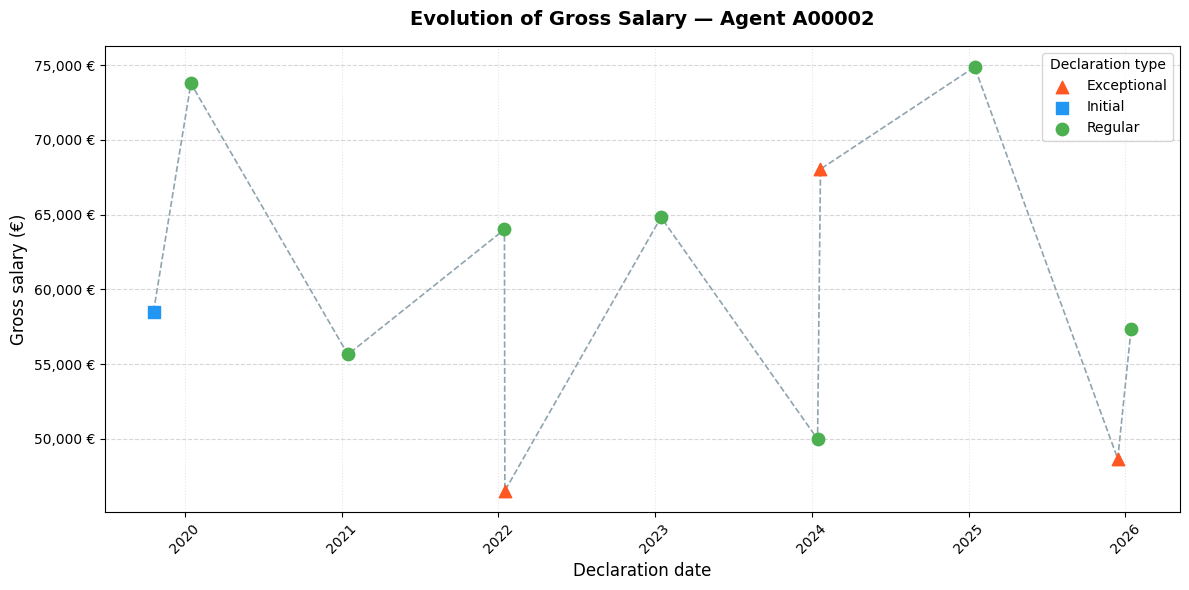

Gráfico guardado em: US15_gross_salary.svg


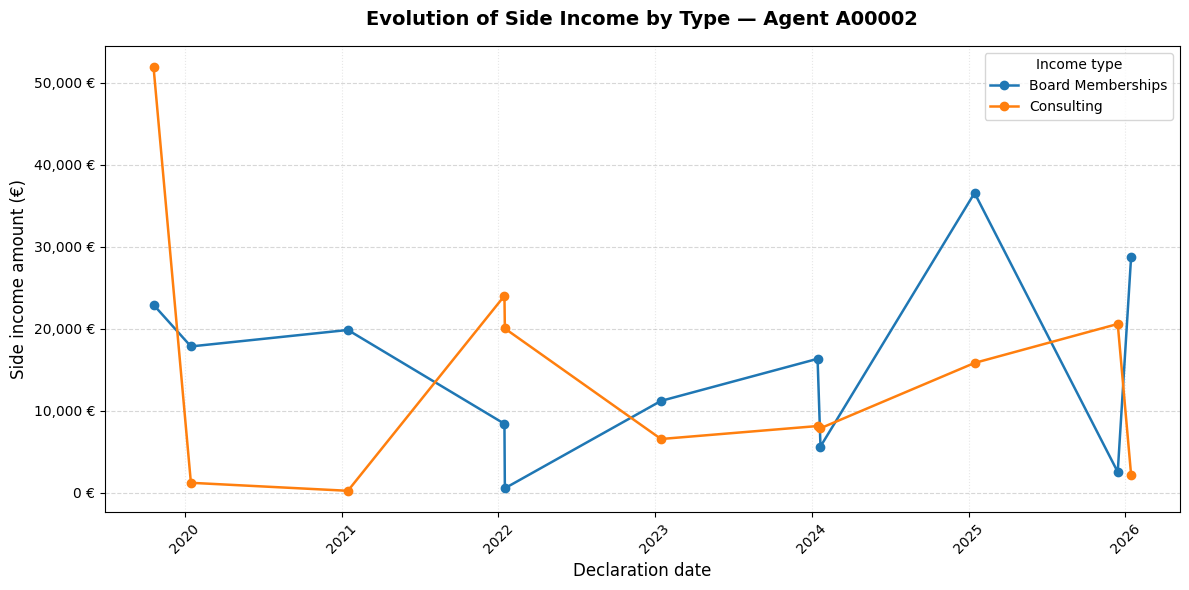

Gráfico guardado em: US15_side_income.svg


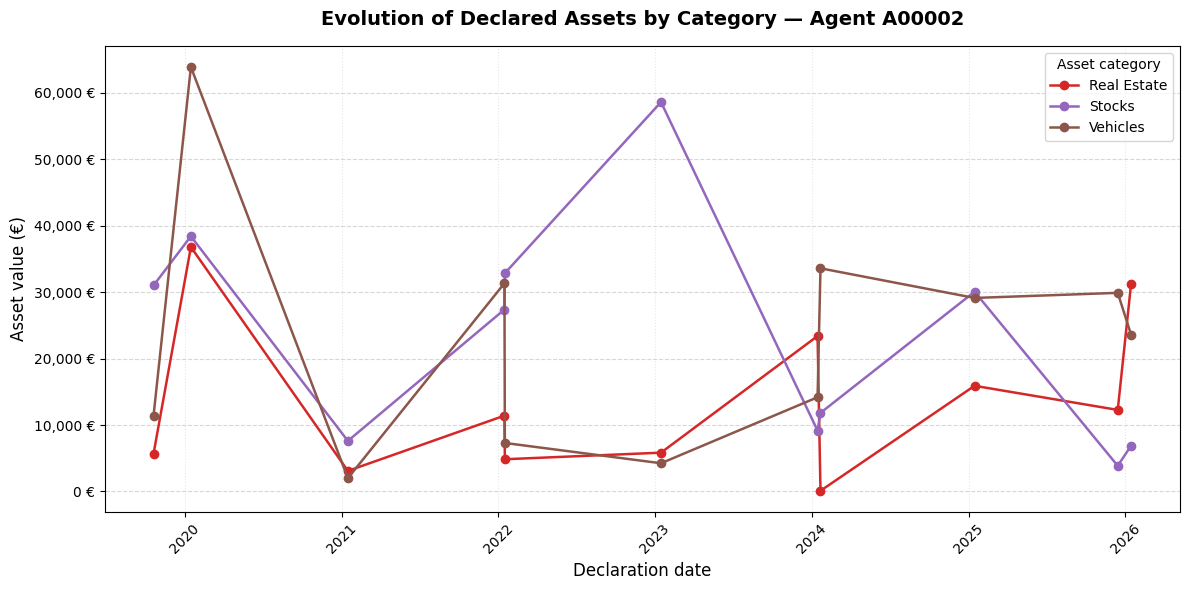

Gráfico guardado em: US15_assets.svg

DESCRIPTIVE INTERPRETATION
  Agent              : A00002
  Role               : MP
  Declarations used  : 11 — {'regular': 7, 'exceptional': 3, 'initial': 1}
  Period             : 2019-10-19 to 2026-01-15

  Gross Salary — decreasing trend (-1.9%)
    First declaration :       58,517 €
    Last declaration  :       57,376 €

  Side Income — most relevant type by average: Board Memberships
    Board Memberships           :     15,509 €
    Consulting                  :     14,413 €

  Declared Assets — largest average category: Stocks
    Stocks                      :     23,429 €
    Vehicles                    :     22,778 €
    Real Estate                 :     13,694 €

  Total Assets — increasing trend (+28.5%)
    First declaration :       48,073 €
    Last declaration  :       61,784 €


In [4]:
# ── Selecção do agente (alterar aqui) ────────────────────────────────────────
selected_agent_id = "A00002"

run_us15_analysis(df, SIDE_INCOME_COLS, ASSET_COLS, selected_agent_id)

# US16 — Comparação do Rendimento Total por Cargo (Role)

**Descrição:**  
Como membro do Comité de Ética, quero obter uma comparação do rendimento total (salário bruto + rendimentos laterais) entre os diferentes cargos. A análise deve usar boxplots para revelar diferenças na tendência central, variabilidade e presença de outliers. O objetivo é identificar qual(ais) cargo(s) apresenta(m) as medianas mais elevadas e qual(ais) exibe(m) maior dispersão, listando e interpretando os outliers detetados.

---

## Conceitos Teóricos Aplicados

### Rendimento Total
O rendimento total de cada agente político é calculado como:

$$\text{total\_income} = \text{gross\_salary} + \text{side\_income\_consulting} + \text{side\_income\_board\_memberships}$$

### Mediana (Medida de Localização Central)
Dado um conjunto de $n$ valores ordenados $x_{(1)} \leq x_{(2)} \leq \ldots \leq x_{(n)}$, a mediana é:

$$\tilde{x} = \begin{cases} \dfrac{x_{(n/2)} + x_{(n/2+1)}}{2}, & \text{se } n \text{ par} \\ x_{((n+1)/2)}, & \text{se } n \text{ ímpar} \end{cases}$$

### Amplitude Interquartil (Medida de Variabilidade)
$$r_q = q_3 - q_1$$
Representa como estão dispersos 50% das observações centrais.

### Outliers — Critério do Boxplot
Um valor é considerado outlier se estiver fora dos limites:
$$[q_1 - 1{,}5 \times r_q \;,\; q_3 + 1{,}5 \times r_q]$$

### Diagrama de Extremos e Quartis (Boxplot)
Representação gráfica dos valores: mínimo, $q_1$, mediana, $q_3$, máximo.
Os outliers são representados isoladamente como pontos fora dos "bigodes".

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Carregamento e limpeza ──────────────────────────────────────────────────
df = pd.read_csv('../Dados/dataset1_declarations.csv')
df.columns = df.columns.str.strip()
df['declaration_date'] = pd.to_datetime(df['declaration_date'])

# ── Cálculo do Rendimento Total ─────────────────────────────────────────────
# total_income = salário bruto + rendimentos de consultoria + rendimentos de memberships
df['total_income'] = (
    df['gross_salary'] +
    df['side_income_consulting'] +
    df['side_income_board_memberships']
)

print(f"Dataset carregado: {df.shape[0]} declarações, {df['agent_id'].nunique()} agentes únicos")
print(f"Cargos presentes: {sorted(df['role'].unique())}")

Dataset carregado: 13395 declarações, 2364 agentes únicos
Cargos presentes: ['Advisor', 'Judge', 'MP', 'Minister', 'State Secretary']


## 1. Medidas Descritivas do Rendimento Total por Cargo

Para cada cargo calculamos as principais medidas de localização e variabilidade do rendimento total.

In [2]:
# ── Medidas descritivas agrupadas por cargo ─────────────────────────────────
# Média, Mediana, Desvio Padrão, Variância, Q1, Q3, Amplitude Interquartil

def medidas_descritivas(grupo):
    q1 = grupo.quantile(0.25)
    q3 = grupo.quantile(0.75)
    return pd.Series({
        'Média':              grupo.mean(),
        'Mediana':            grupo.median(),
        'Desvio Padrão':      grupo.std(),
        'Variância':          grupo.var(),
        'Q1 (25%)':           q1,
        'Q3 (75%)':           q3,
        'Amplitude Interquartil (IQR)': q3 - q1,
        'Mínimo':             grupo.min(),
        'Máximo':             grupo.max(),
        'N (declarações)':    grupo.count()
    })

tabela = df.groupby('role')['total_income'].apply(medidas_descritivas)
# No pandas moderno o resultado pode ter MultiIndex — garantir estrutura correcta
if isinstance(tabela.index, pd.MultiIndex):
    tabela = tabela.unstack(level=0)
else:
    tabela = tabela.T

# Ordenar colunas pela mediana decrescente
ordem = tabela.loc['Mediana'].sort_values(ascending=False).index
tabela = tabela[ordem]

print("=" * 90)
print("MEDIDAS DESCRITIVAS DO RENDIMENTO TOTAL POR CARGO")
print("=" * 90)
print(tabela.map(lambda x: f"{x:,.2f}" if isinstance(x, float) else str(x)).to_string())
print()
print(f"→ Cargo com mediana mais elevada : {tabela.loc['Mediana'].idxmax()}")
print(f"→ Cargo com maior dispersão (IQR): {tabela.loc['Amplitude Interquartil (IQR)'].idxmax()}")
print(f"→ Cargo com maior desvio padrão  : {tabela.loc['Desvio Padrão'].idxmax()}")

MEDIDAS DESCRITIVAS DO RENDIMENTO TOTAL POR CARGO
role                                        MP           Advisor   State Secretary        Minister             Judge
Média                               101,061.63        101,270.07        100,297.60       96,156.69         99,711.46
Mediana                              96,782.07         96,513.30         95,452.29       95,311.96         94,857.93
Desvio Padrão                        32,878.24         32,854.22         33,447.63       31,015.85         32,127.13
Variância                     1,080,978,869.77  1,079,400,071.19  1,118,743,714.02  961,983,090.59  1,032,152,522.97
Q1 (25%)                             78,556.45         79,122.16         77,431.62       74,221.19         77,199.42
Q3 (75%)                            118,637.58        118,802.40        117,786.86      111,907.25        116,453.33
Amplitude Interquartil (IQR)         40,081.12         39,680.24         40,355.24       37,686.07         39,253.91
Mínimo        

## 2. Boxplot — Comparação do Rendimento Total por Cargo

O boxplot permite visualizar simultaneamente a mediana, a dispersão interquartil e a presença de outliers para cada cargo.

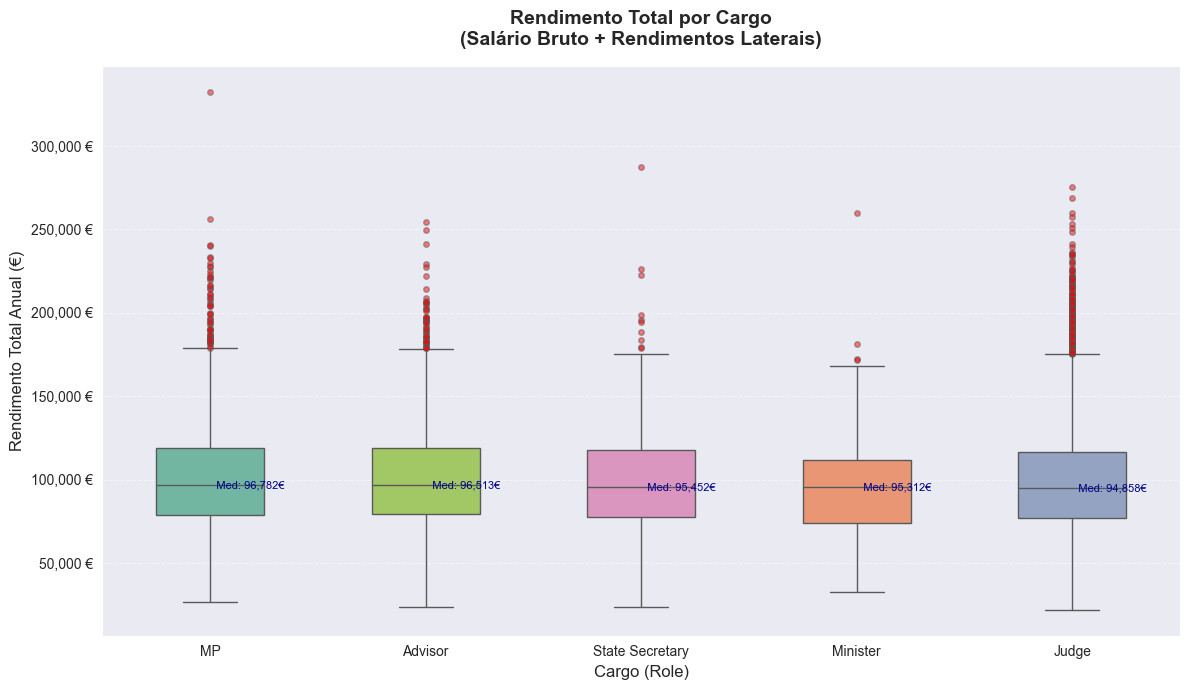

Gráfico guardado em: US16_boxplot_rendimento_por_cargo.svg


In [3]:
# ── Ordem dos cargos por mediana decrescente ────────────────────────────────
ordem_cargos = (
    df.groupby('role')['total_income']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df,
    x='role', y='total_income',
    order=ordem_cargos,
    hue='role', palette='Set2', legend=False,
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5),
    ax=ax
)

ax.set_title(
    'Rendimento Total por Cargo\n'
    '(Salário Bruto + Rendimentos Laterais)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Cargo (Role)', fontsize=12)
ax.set_ylabel('Rendimento Total Anual (€)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Anotar a mediana em cada caixa
medianas = df.groupby('role')['total_income'].median()
for i, cargo in enumerate(ordem_cargos):
    ax.text(
        i, medianas[cargo],
        f'  Med: {medianas[cargo]:,.0f}€',
        va='center', fontsize=8, color='darkblue'
    )

plt.tight_layout()
plt.savefig('US16_boxplot_rendimento_por_cargo.svg', format='svg', bbox_inches='tight')
plt.show()
print("Gráfico guardado em: US16_boxplot_rendimento_por_cargo.svg")

## 3. Identificação e Interpretação de Outliers

Usando o critério standard do boxplot:  
$$\text{Outlier se } x < q_1 - 1{,}5 \times IQR \quad \text{ou} \quad x > q_3 + 1{,}5 \times IQR$$

In [4]:
# ── Deteção de Outliers por Cargo ───────────────────────────────────────────
resumo_outliers = []

print("=" * 90)
print("OUTLIERS DETETADOS — RENDIMENTO TOTAL POR CARGO")
print("=" * 90)

for cargo in ordem_cargos:
    sub = df[df['role'] == cargo]['total_income']
    q1  = sub.quantile(0.25)
    q3  = sub.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers_inf = sub[sub < lim_inf]
    outliers_sup = sub[sub > lim_sup]
    todos = pd.concat([outliers_inf, outliers_sup]).sort_values()

    print(f"\nCargo: {cargo}")
    print(f"  Q1={q1:,.0f}€ | Q3={q3:,.0f}€ | IQR={iqr:,.0f}€")
    print(f"  Limite inferior: {lim_inf:,.0f}€ | Limite superior: {lim_sup:,.0f}€")
    print(f"  Outliers inferiores: {len(outliers_inf)} | Outliers superiores: {len(outliers_sup)} | Total: {len(todos)}")

    if len(todos) > 0:
        print(f"  Min outlier: {todos.min():,.0f}€ | Max outlier: {todos.max():,.0f}€")

    resumo_outliers.append({
        'Cargo':              cargo,
        'N Outliers':         len(todos),
        'Outliers Inf.':      len(outliers_inf),
        'Outliers Sup.':      len(outliers_sup),
        'Limite Inferior (€)': round(lim_inf, 2),
        'Limite Superior (€)': round(lim_sup, 2)
    })

# Tabela resumo
print("\n" + "=" * 90)
print("RESUMO DE OUTLIERS")
print(pd.DataFrame(resumo_outliers).set_index('Cargo').to_string())

OUTLIERS DETETADOS — RENDIMENTO TOTAL POR CARGO

Cargo: MP
  Q1=78,556€ | Q3=118,638€ | IQR=40,081€
  Limite inferior: 18,435€ | Limite superior: 178,759€
  Outliers inferiores: 0 | Outliers superiores: 59 | Total: 59
  Min outlier: 178,789€ | Max outlier: 332,624€

Cargo: Advisor
  Q1=79,122€ | Q3=118,802€ | IQR=39,680€
  Limite inferior: 19,602€ | Limite superior: 178,323€
  Outliers inferiores: 0 | Outliers superiores: 47 | Total: 47
  Min outlier: 178,858€ | Max outlier: 254,288€

Cargo: State Secretary
  Q1=77,432€ | Q3=117,787€ | IQR=40,355€
  Limite inferior: 16,899€ | Limite superior: 178,320€
  Outliers inferiores: 0 | Outliers superiores: 10 | Total: 10
  Min outlier: 178,714€ | Max outlier: 287,333€

Cargo: Minister
  Q1=74,221€ | Q3=111,907€ | IQR=37,686€
  Limite inferior: 17,692€ | Limite superior: 168,436€
  Outliers inferiores: 0 | Outliers superiores: 4 | Total: 4
  Min outlier: 171,768€ | Max outlier: 259,849€

Cargo: Judge
  Q1=77,199€ | Q3=116,453€ | IQR=39,254€
  L

## 4. Interpretação dos Resultados

Com base na análise efectuada, é possível retirar as seguintes conclusões:

In [5]:
# ── Interpretação automática ────────────────────────────────────────────────
tab = pd.DataFrame(resumo_outliers).set_index('Cargo')
medianas_cargo = df.groupby('role')['total_income'].median()
iqr_cargo      = df.groupby('role')['total_income'].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))

cargo_maior_mediana  = medianas_cargo.idxmax()
cargo_maior_disp     = iqr_cargo.idxmax()
cargo_mais_outliers  = tab['N Outliers'].idxmax()

print("INTERPRETAÇÃO")
print("-" * 60)
print(f"• Cargo com mediana mais elevada  : {cargo_maior_mediana} ({medianas_cargo[cargo_maior_mediana]:,.0f} €)")
print(f"  → É o cargo com o rendimento típico mais alto.")
print()
print(f"• Cargo com maior dispersão (IQR) : {cargo_maior_disp} ({iqr_cargo[cargo_maior_disp]:,.0f} €)")
print(f"  → Os rendimentos neste cargo variam mais entre os agentes.")
print()
print(f"• Cargo com mais outliers         : {cargo_mais_outliers} ({tab.loc[cargo_mais_outliers, 'N Outliers']} outliers)")
print(f"  → Existem agentes com rendimentos atipicamente elevados ou baixos.")
print()
print("• Outliers superiores indicam possíveis rendimentos laterais muito")
print("  elevados (consulting ou board memberships) que merecem atenção")
print("  do Comité de Ética quanto a potenciais conflitos de interesse.")

INTERPRETAÇÃO
------------------------------------------------------------
• Cargo com mediana mais elevada  : MP (96,782 €)
  → É o cargo com o rendimento típico mais alto.

• Cargo com maior dispersão (IQR) : State Secretary (40,355 €)
  → Os rendimentos neste cargo variam mais entre os agentes.

• Cargo com mais outliers         : Judge (236 outliers)
  → Existem agentes com rendimentos atipicamente elevados ou baixos.

• Outliers superiores indicam possíveis rendimentos laterais muito
  elevados (consulting ou board memberships) que merecem atenção
  do Comité de Ética quanto a potenciais conflitos de interesse.


# US17 — Top 10 Empresas com Maior Valor de Ações Detidas por Agentes Políticos

**Descrição:**  
Como membro do Comité de Ética, quero obter um gráfico que apresente as dez empresas com os maiores valores totais de ações detidas por agentes políticos, juntamente com os respetivos montantes. Para cada agente político, apenas a declaração mais recente será considerada.

---

## Conceitos Teóricos Aplicados

### Frequência Absoluta
O valor total de ações por empresa é obtido somando os valores de todos os agentes que detêm ações nessa empresa (usando apenas a declaração mais recente de cada agente):

$$n_i = \sum_{j=1}^{k} \text{total\_value\_in\_stocks}_{ij}$$

onde $k$ é o número de agentes com posições na empresa $i$.

### Ranking / Ordenação
Após calcular o valor total por empresa, ordenamos de forma decrescente e selecionamos as 10 primeiras — correspondendo às empresas com maior exposição a ativos de agentes políticos.

### Gráfico de Barras
Representação em que cada barra tem altura proporcional à frequência (valor total) da categoria correspondente, permitindo comparação visual directa entre empresas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Carregamento e limpeza ──────────────────────────────────────────────────
df = pd.read_csv('../Dados/dataset2_holdings.csv')
df.columns = df.columns.str.strip()
df['declaration_date'] = pd.to_datetime(df['declaration_date'])

print(f"Dataset carregado: {df.shape[0]} registos")
print(f"Agentes únicos  : {df['agent_id'].nunique()}")
print(f"Empresas únicas : {df['company_NIF'].nunique()}")
print()
print(df.head())

Dataset carregado: 953 registos
Agentes únicos  : 135
Empresas únicas : 92

  agent_id  company_NIF  total_value_in_stocks  company_percentage  \
0   A00128    100000066              157039.75               11.42   
1   A00128    100000066              158976.75                2.95   
2   A00128    100000066              160913.75               11.75   
3   A00092    100000031              145789.76                0.52   
4   A00092    100000031              151637.13               24.81   

  declaration_date  
0       2020-05-10  
1       2021-02-04  
2       2021-07-18  
3       2018-05-11  
4       2020-02-09  


## 1. Selecção da Declaração Mais Recente por Agente

Conforme especificado no enunciado, para cada agente político considera-se apenas a declaração mais recente.  
Como um agente pode ter ações em várias empresas na mesma data, seleccionamos todos os registos cuja data corresponde à data máxima do agente.

In [2]:
# ── Data mais recente por agente ────────────────────────────────────────────
data_mais_recente = (
    df.groupby('agent_id')['declaration_date']
    .max()
    .reset_index()
    .rename(columns={'declaration_date': 'max_date'})
)

# Juntar ao dataset original para filtrar apenas os registos mais recentes
df_recente = df.merge(data_mais_recente, on='agent_id')
df_recente = df_recente[df_recente['declaration_date'] == df_recente['max_date']].copy()

print(f"Registos antes do filtro : {df.shape[0]}")
print(f"Registos após filtro     : {df_recente.shape[0]}")
print(f"Agentes representados    : {df_recente['agent_id'].nunique()}")

Registos antes do filtro : 953
Registos após filtro     : 136
Agentes representados    : 135


## 2. Cálculo do Valor Total de Ações por Empresa

Somamos o `total_value_in_stocks` de todos os agentes para cada empresa, usando apenas as declarações mais recentes.

In [3]:
# ── Valor total por empresa ─────────────────────────────────────────────────
valor_por_empresa = (
    df_recente.groupby('company_NIF')['total_value_in_stocks']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
valor_por_empresa.columns = ['company_NIF', 'total_value']

# Número de agentes por empresa (informação adicional)
agentes_por_empresa = (
    df_recente.groupby('company_NIF')['agent_id']
    .nunique()
    .reset_index()
    .rename(columns={'agent_id': 'n_agents'})
)
valor_por_empresa = valor_por_empresa.merge(agentes_por_empresa, on='company_NIF')

# Top 10
top10 = valor_por_empresa.head(10).copy()
top10['company_NIF'] = top10['company_NIF'].astype(str)  # NIF como string para o eixo

print("TOP 10 EMPRESAS — VALOR TOTAL DE AÇÕES DETIDAS POR AGENTES POLÍTICOS")
print("=" * 65)
print(f"{'Rank':<5} {'NIF Empresa':<15} {'Valor Total (€)':>18} {'Nº Agentes':>12}")
print("-" * 55)
for i, row in top10.iterrows():
    rank = valor_por_empresa.index.get_loc(i) + 1
    print(f"{rank:<5} {row['company_NIF']:<15} {row['total_value']:>18,.2f} {row['n_agents']:>12}")

TOP 10 EMPRESAS — VALOR TOTAL DE AÇÕES DETIDAS POR AGENTES POLÍTICOS
Rank  NIF Empresa        Valor Total (€)   Nº Agentes
-------------------------------------------------------
1     100000031               661,372.12            5
2     100000069               626,334.79            4
3     100000064               564,134.33            3
4     100000040               552,342.37            2
5     100000000               511,550.02            2
6     100000080               484,236.94            4
7     100000091               470,563.11            2
8     100000010               467,310.70            3
9     100000068               458,345.84            3
10    100000058               440,384.11            3


## 3. Gráfico — Top 10 Empresas por Valor Total de Ações

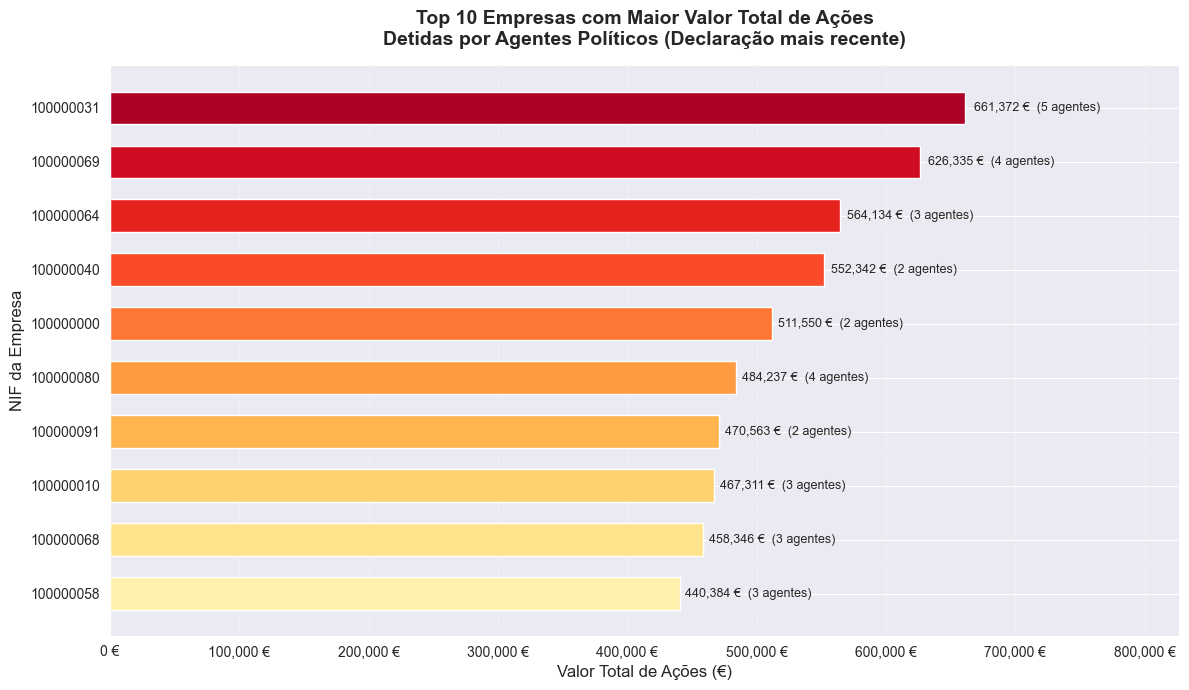

Gráfico guardado em: US17_top10_empresas_acoes.svg


In [4]:
# ── Gráfico de barras horizontais ───────────────────────────────────────────
# Barras horizontais facilitam a leitura dos NIFs e a comparação de valores

fig, ax = plt.subplots(figsize=(12, 7))

cores = sns.color_palette('YlOrRd', n_colors=10)[::-1]  # mais escuro = maior valor

barras = ax.barh(
    y=top10['company_NIF'],
    width=top10['total_value'],
    color=cores,
    edgecolor='white',
    height=0.6
)

# Ordenar do maior para o menor (de cima para baixo)
ax.invert_yaxis()

# Anotação do valor em cada barra
for barra, (_, row) in zip(barras, top10.iterrows()):
    ax.text(
        barra.get_width() + barra.get_width() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{row['total_value']:,.0f} €  ({row['n_agents']} agentes)",
        va='center', ha='left', fontsize=9
    )

ax.set_title(
    'Top 10 Empresas com Maior Valor Total de Ações\nDetidas por Agentes Políticos (Declaração mais recente)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Valor Total de Ações (€)', fontsize=12)
ax.set_ylabel('NIF da Empresa', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
ax.set_xlim(0, top10['total_value'].max() * 1.25)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('US17_top10_empresas_acoes.svg', format='svg', bbox_inches='tight')
plt.show()
print("Gráfico guardado em: US17_top10_empresas_acoes.svg")

## 4. Interpretação dos Resultados

In [5]:
# ── Interpretação automática ────────────────────────────────────────────────
empresa_topo   = top10.iloc[0]
empresa_fundo  = top10.iloc[9]
total_top10    = top10['total_value'].sum()
total_geral    = valor_por_empresa['total_value'].sum()
pct_top10      = total_top10 / total_geral * 100

print("INTERPRETAÇÃO")
print("-" * 60)
print(f"• Empresa com maior exposição : NIF {empresa_topo['company_NIF']}")
print(f"  Valor total                 : {empresa_topo['total_value']:,.2f} €")
print(f"  Nº de agentes com posições  : {empresa_topo['n_agents']}")
print()
print(f"• O Top 10 representa {pct_top10:.1f}% do valor total de ações")
print(f"  declaradas por todos os agentes políticos ({total_geral:,.2f} €).")
print()
print(f"• Empresas com muitos agentes políticos como detentores de ações")
print(f"  e/ou com valores muito elevados podem constituir potenciais")
print(f"  conflitos de interesse a investigar pelo Comité de Ética.")

INTERPRETAÇÃO
------------------------------------------------------------
• Empresa com maior exposição : NIF 100000031
  Valor total                 : 661,372.12 €
  Nº de agentes com posições  : 5

• O Top 10 representa 32.9% do valor total de ações
  declaradas por todos os agentes políticos (15,905,829.37 €).

• Empresas com muitos agentes políticos como detentores de ações
  e/ou com valores muito elevados podem constituir potenciais
  conflitos de interesse a investigar pelo Comité de Ética.


# US 18

In [1]:
## Importar Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load and prepare holdings data for actor-company pair analysis.
holdings_df = pd.read_csv("../Dados/dataset2_holdings.csv")
rows_before = len(holdings_df)

required_columns = [
    "agent_id",
    "company_NIF",
    "total_value_in_stocks",
    "declaration_date",
]

analysis_df = holdings_df.copy()
analysis_df["declaration_date"] = pd.to_datetime(analysis_df["declaration_date"], errors="coerce")
analysis_df["total_value_in_stocks"] = pd.to_numeric(
    analysis_df["total_value_in_stocks"], errors="coerce"
)
analysis_df["agent_id"] = analysis_df["agent_id"].astype(str).str.strip()
analysis_df["company_NIF"] = analysis_df["company_NIF"].astype(str).str.strip()

analysis_df = analysis_df.dropna(
    subset=["agent_id", "company_NIF", "declaration_date", "total_value_in_stocks"]
).copy()

analysis_df = (
    analysis_df.groupby(["agent_id", "company_NIF", "declaration_date"], as_index=False)["total_value_in_stocks"]
    .sum()
    .sort_values(["agent_id", "company_NIF", "declaration_date"])
    .reset_index(drop=True)
)
analysis_df["pair_label"] = analysis_df["agent_id"] + " | " + analysis_df["company_NIF"]

pair_summary = (
    analysis_df.groupby(["agent_id", "company_NIF", "pair_label"], as_index=False)
    .agg(
        start_date=("declaration_date", "first"),
        end_date=("declaration_date", "last"),
        initial_value=("total_value_in_stocks", "first"),
        recent_value=("total_value_in_stocks", "last"),
        observations=("total_value_in_stocks", "size"),
    )
)

pair_summary["increase"] = pair_summary["recent_value"] - pair_summary["initial_value"]
pair_summary["increase_pct"] = np.where(
    pair_summary["initial_value"] != 0,
    (pair_summary["increase"] / pair_summary["initial_value"]) * 100,
    np.nan,
)

top10_pairs = (
    pair_summary.sort_values(
        by=["increase", "recent_value", "agent_id", "company_NIF"],
        ascending=[False, False, True, True],
    )
    .head(10)
    .reset_index(drop=True)
)

print(f"Total rows loaded: {rows_before}")
print(f"Rows after cleaning and daily aggregation: {len(analysis_df)}")
print(f"Unique actor-company pairs analyzed: {pair_summary.shape[0]}")
print()

top10_display = top10_pairs[[
    "pair_label",
    "initial_value",
    "recent_value",
    "increase",
    "increase_pct",
    "start_date",
    "end_date",
    "observations",
]].copy()
top10_display["start_date"] = top10_display["start_date"].dt.date
top10_display["end_date"] = top10_display["end_date"].dt.date
top10_display[["initial_value", "recent_value", "increase", "increase_pct"]] = (
    top10_display[["initial_value", "recent_value", "increase", "increase_pct"]].round(2)
)

print("Top 10 actor-company pairs by increase in stock value:")
print(top10_display)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "figure.facecolor": "white",
        "axes.facecolor": "#f8f9fa",
    }
)

Total rows loaded: 953
Rows after cleaning and daily aggregation: 952
Unique actor-company pairs analyzed: 267

Top 10 actor-company pairs by increase in stock value:
           pair_label  initial_value  recent_value   increase  increase_pct  \
0  A00049 | 100000096       27081.42     322836.95  295755.53       1092.10   
1  A00054 | 100000048       94531.47     388940.59  294409.12        311.44   
2  A00074 | 100000084      169621.56     450026.28  280404.72        165.31   
3  A00095 | 100000055       95466.62     370048.28  274581.66        287.62   
4  A00051 | 100000080       41381.16     311297.68  269916.52        652.27   
5  A00092 | 100000073       63183.01     318368.22  255185.21        403.88   
6  A00059 | 100000037      109034.83     347936.12  238901.29        219.11   
7  A00036 | 100000071       72312.47     308986.13  236673.66        327.29   
8  A00068 | 100000000      133759.03     367783.38  234024.35        174.96   
9  A00006 | 100000003       82267.19     31

### Graph 1: Top 10 Increases by Actor-Company Pair

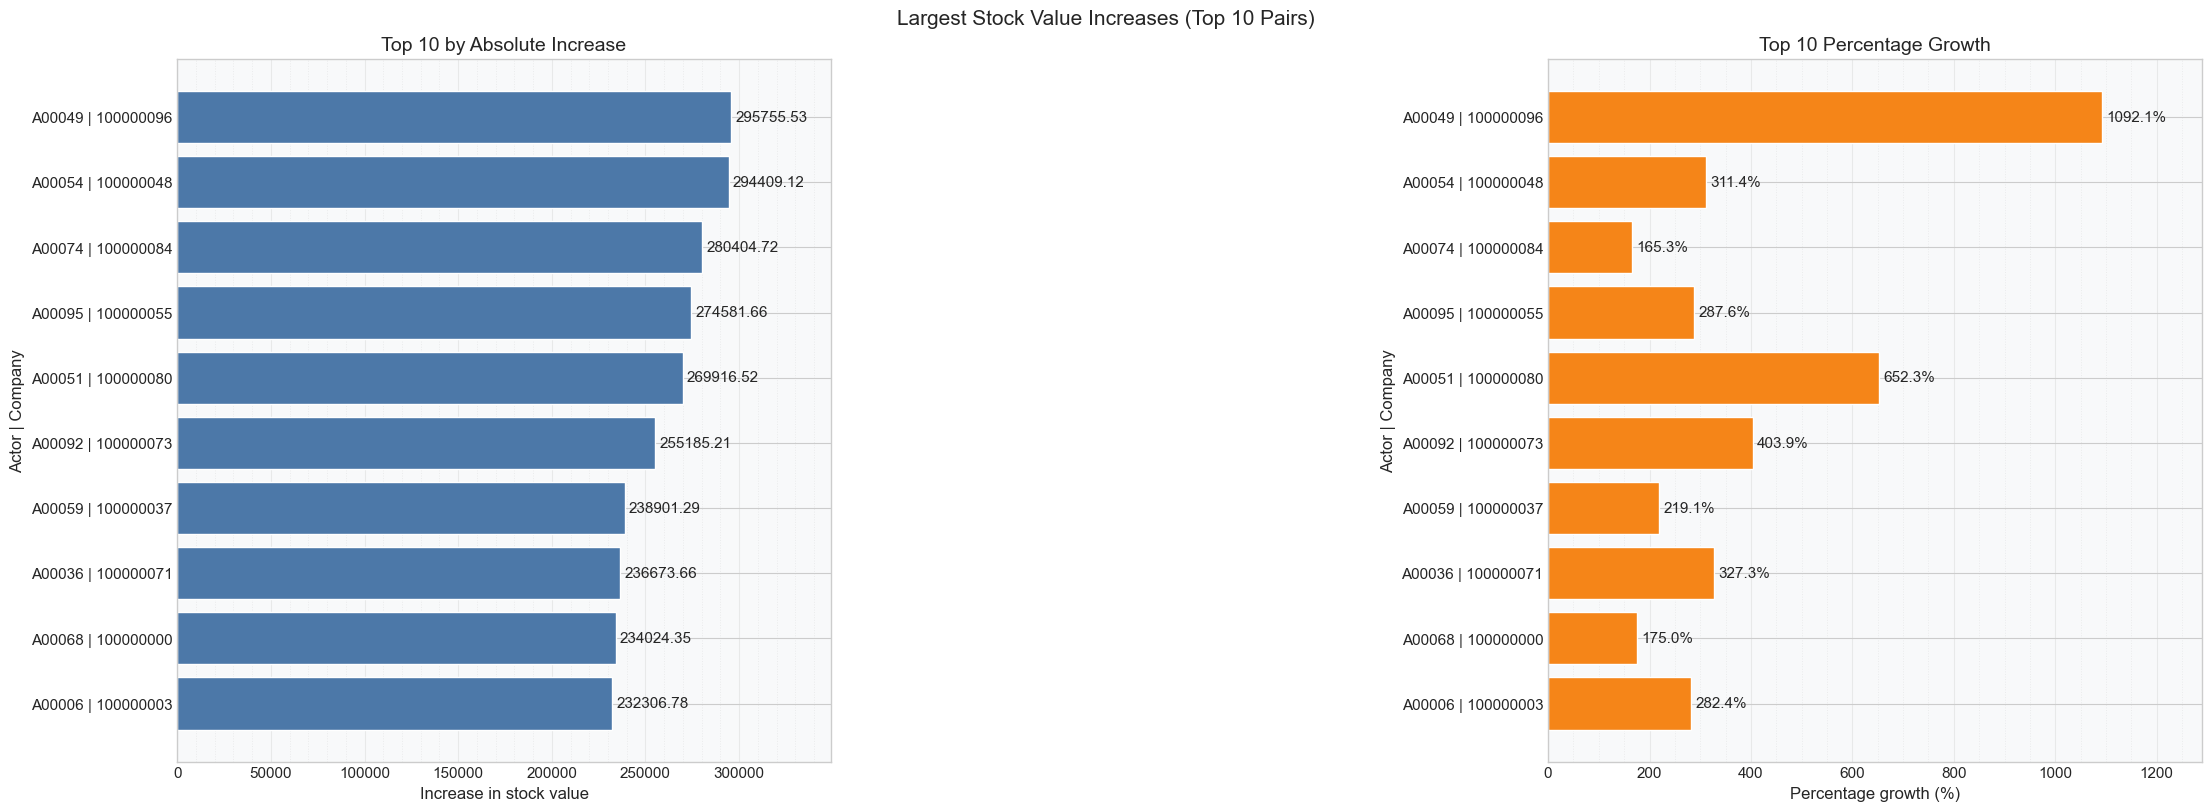

In [3]:
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(22, 8),
    gridspec_kw={"wspace": 0.50},
    constrained_layout=True,
)

ranking_plot_df = top10_pairs.sort_values("increase", ascending=True)

bars_abs = ax1.barh(
    ranking_plot_df["pair_label"],
    ranking_plot_df["increase"],
    color="#4C78A8",
)
abs_max = ranking_plot_df["increase"].max()
ax1.set_xlim(0, abs_max * 1.18)
ax1.set_title("Top 10 by Absolute Increase")
ax1.set_xlabel("Increase in stock value")
ax1.set_ylabel("Actor | Company")
ax1.set_axisbelow(True)
ax1.minorticks_on()
ax1.grid(axis="x", which="major", linestyle="-", linewidth=0.8, alpha=0.35)
ax1.grid(axis="x", which="minor", linestyle=":", linewidth=0.7, alpha=0.30)
ax1.bar_label(bars_abs, fmt="%.2f", padding=3)

bars_pct = ax2.barh(
    ranking_plot_df["pair_label"],
    ranking_plot_df["increase_pct"],
    color="#F58518",
)
pct_max = ranking_plot_df["increase_pct"].max()
ax2.set_xlim(0, pct_max * 1.18)
ax2.set_title("Top 10 Percentage Growth")
ax2.set_xlabel("Percentage growth (%)")
ax2.set_ylabel("Actor | Company")
ax2.set_axisbelow(True)
ax2.minorticks_on()
ax2.grid(axis="x", which="major", linestyle="-", linewidth=0.8, alpha=0.35)
ax2.grid(axis="x", which="minor", linestyle=":", linewidth=0.7, alpha=0.30)
ax2.bar_label(bars_pct, fmt="%.1f%%", padding=3)

fig.suptitle("Largest Stock Value Increases (Top 10 Pairs)", fontsize=15)
plt.show()

### Graph 2: Evolution Over Time for the Top 10 Pairs

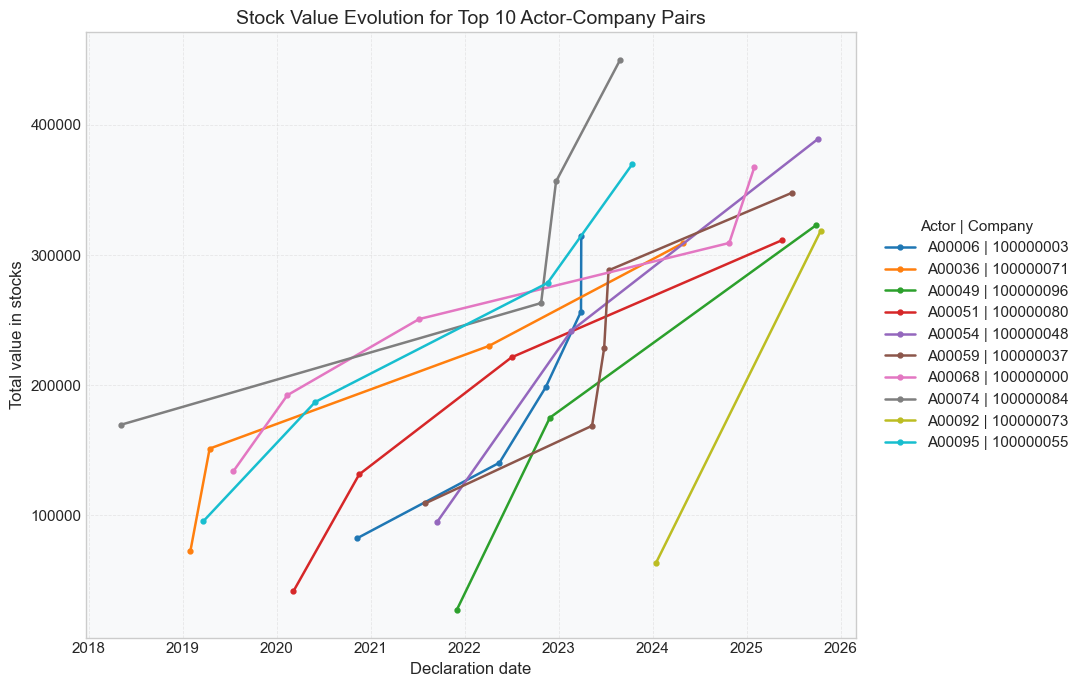

In [4]:
selected_pairs = top10_pairs[["agent_id", "company_NIF", "pair_label"]].copy()
evolution_df = analysis_df.merge(
    selected_pairs, on=["agent_id", "company_NIF", "pair_label"], how="inner"
)

fig, ax = plt.subplots(figsize=(11, 7))

for pair_label, group in evolution_df.groupby("pair_label"):
    group = group.sort_values("declaration_date")
    ax.plot(
        group["declaration_date"],
        group["total_value_in_stocks"],
        marker="o",
        linewidth=1.8,
        markersize=3.5,
        label=pair_label,
    )

ax.set_title("Stock Value Evolution for Top 10 Actor-Company Pairs")
ax.set_xlabel("Declaration date")
ax.set_ylabel("Total value in stocks")
ax.grid(axis="both", linestyle="--", linewidth=0.6, alpha=0.4)
ax.legend(title="Actor | Company", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.tight_layout()
plt.show()

In [5]:
top_pair = top10_pairs.iloc[0]
top_pair_pct = top10_pairs.loc[top10_pairs["increase_pct"].idxmax()]
median_increase = top10_pairs["increase"].median()
median_increase_pct = top10_pairs["increase_pct"].median()

trend_flags = []
for _, pair in top10_pairs.iterrows():
    mask = (analysis_df["agent_id"] == pair["agent_id"]) & (
        analysis_df["company_NIF"] == pair["company_NIF"]
    )
    pair_series = analysis_df.loc[mask].sort_values("declaration_date")["total_value_in_stocks"]
    trend_flags.append(pair_series.is_monotonic_increasing)

monotonic_count = int(sum(trend_flags))
volatile_count = int(len(trend_flags) - monotonic_count)

print("Interpretation:")
print(
    f"- The pair with the largest absolute increase is '{top_pair['pair_label']}', "
    f"rising from {top_pair['initial_value']:.2f} to {top_pair['recent_value']:.2f} "
    f"(increase of {top_pair['increase']:.2f})."
 )
print(
    f"- The pair with the largest percentage growth is '{top_pair_pct['pair_label']}' "
    f"with {top_pair_pct['increase_pct']:.2f}% growth."
 )
print(
    f"- The median increase among the top 10 pairs is {median_increase:.2f}, "
    f"and the median percentage growth is {median_increase_pct:.2f}%."
 )
print(
    f"- Within the top 10, {monotonic_count} pairs show a monotonic increase over time, "
    f"while {volatile_count} show at least one decline between declarations."
 )
print("- Pair labels use IDs only (agent_id and company_NIF), as actor/company names are not in the source data.")

Interpretation:
- The pair with the largest absolute increase is 'A00049 | 100000096', rising from 27081.42 to 322836.95 (increase of 295755.53).
- The pair with the largest percentage growth is 'A00049 | 100000096' with 1092.10% growth.
- The median increase among the top 10 pairs is 262550.86, and the median percentage growth is 299.53%.
- Within the top 10, 10 pairs show a monotonic increase over time, while 0 show at least one decline between declarations.
- Pair labels use IDs only (agent_id and company_NIF), as actor/company names are not in the source data.
